<a href="https://colab.research.google.com/github/PraeyOfTheGods/sephora-skincare-recommendation-week1-/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA Summary

The exploratory data analysis identified several important patterns in the Sephora skincare review data:

- The product catalog contains 2,420 skincare products.
- Skincare products are concentrated in categories such as Moisturizers, Treatments, and Cleansers.
- Skincare product prices vary substantially, with a median price of about $44.
- Product ratings are generally high, with a median rating of about 4.31.
- There is almost no linear relationship between product price and rating (correlation ≈ -0.005).
- The relationship between product review count and rating is also weak (correlation ≈ 0.078).
- Combination skin is the most common skin type in the review data.
- Most reviewers contribute only a single review, highlighting the importance of handling sparse user histories.
- Recommendation rates increase strongly with rating, with 4- and 5-star reviews being recommended much more frequently than lower-rated reviews.
- Recommendation rates vary somewhat across skin types and skin tones, suggesting that customer profile information may provide useful personalization signals.
- Reviews with higher ratings tend to have higher helpfulness scores.
- Recommended reviews also have higher average helpfulness than non-recommended reviews.
- Review text is generally short to moderate in length, but a small number of reviews are much longer.
- Common review vocabulary includes skincare-related terms such as "skin", "product", "face", "dry", and "moisturizer".
- The review text requires preprocessing before NLP analysis because contractions and punctuation create fragments such as "t", "s", and "ve".

These findings will guide the feature engineering, sentiment analysis, and personalized recommendation stages of the project.

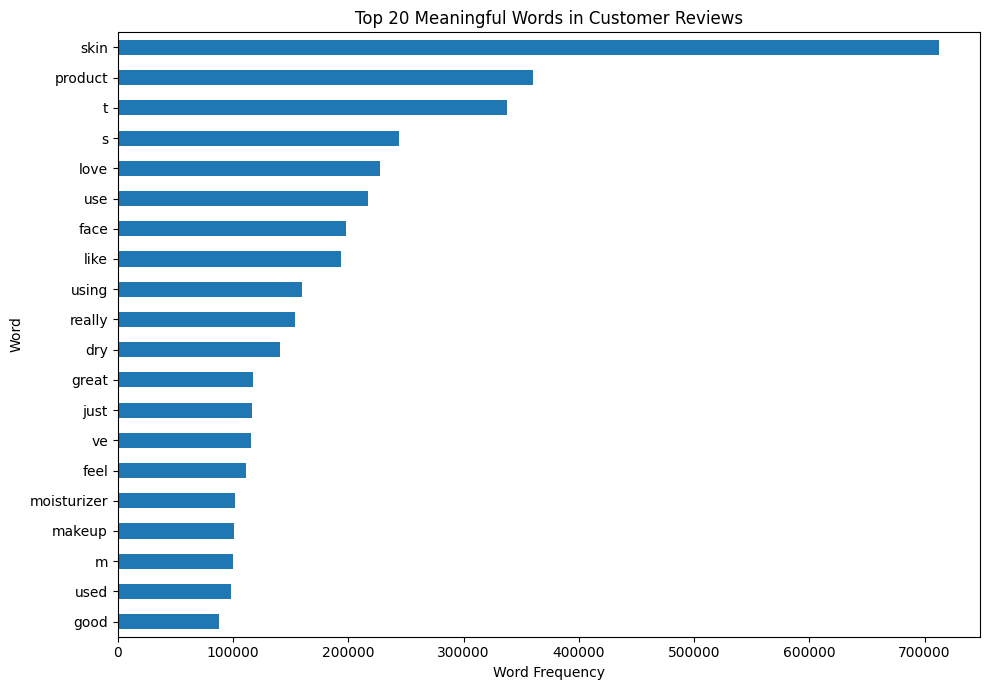

In [52]:
# Top 20 meaningful words in review text

top_words = pd.Series(
    dict(meaningful_word_counts.most_common(20))
).sort_values()

plt.figure(figsize=(10, 7))

top_words.plot(kind="barh")

plt.title("Top 20 Meaningful Words in Customer Reviews")
plt.xlabel("Word Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [51]:
# Most common meaningful words in review text

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

meaningful_words = [
    word
    for word in words
    if word not in ENGLISH_STOP_WORDS
]

meaningful_word_counts = Counter(meaningful_words)

print(meaningful_word_counts.most_common(20))

[('skin', 712509), ('product', 360207), ('t', 338012), ('s', 244200), ('love', 227693), ('use', 217084), ('face', 197848), ('like', 194111), ('using', 160102), ('really', 153940), ('dry', 141180), ('great', 117238), ('just', 116767), ('ve', 115213), ('feel', 111371), ('moisturizer', 101911), ('makeup', 100679), ('m', 99694), ('used', 98284), ('good', 87800)]


In [50]:
# Most common words in review text

from collections import Counter
import re

text = " ".join(
    reviews_0_250["review_text"]
    .dropna()
    .astype(str)
    .str.lower()
)

words = re.findall(r"\b[a-z]+\b", text)

word_counts = Counter(words)

print(word_counts.most_common(20))

[('i', 1921042), ('it', 1400748), ('and', 1260021), ('the', 1066123), ('my', 1027837), ('this', 952957), ('a', 930169), ('skin', 712509), ('to', 664368), ('is', 530068), ('for', 454689), ('of', 379871), ('product', 360207), ('but', 351889), ('t', 338012), ('have', 328644), ('in', 318154), ('so', 305136), ('on', 297612), ('that', 292157)]


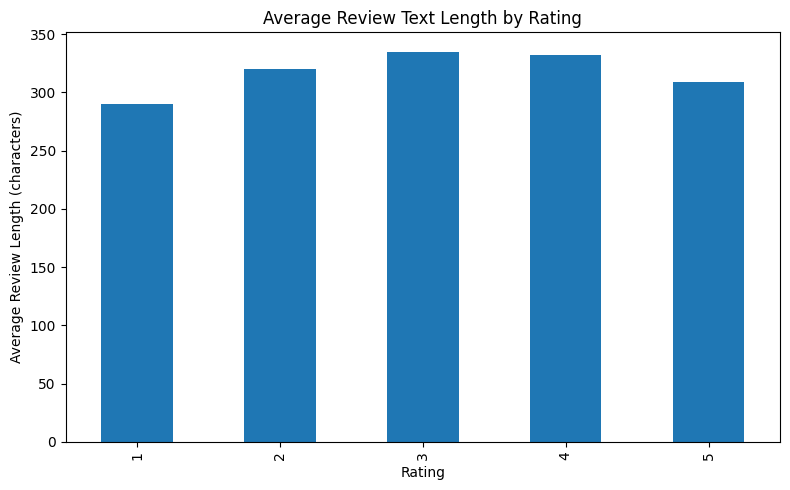

In [49]:
# Average review text length by rating

plt.figure(figsize=(8, 5))

text_length_by_rating.plot(kind="bar")

plt.title("Average Review Text Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Review Length (characters)")

plt.tight_layout()
plt.show()

In [48]:
# Average review text length by rating

text_length_by_rating = (
    reviews_0_250
    .groupby("rating")["review_text_length"]
    .mean()
)

print(text_length_by_rating)

rating
1    290.340243
2    320.360544
3    334.773297
4    331.828687
5    308.491530
Name: review_text_length, dtype: float64


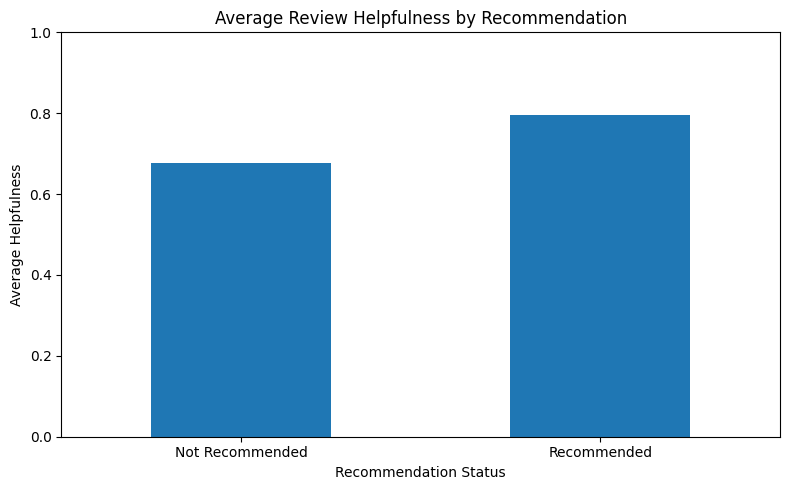

In [47]:
# Average helpfulness by recommendation status

plt.figure(figsize=(8, 5))

helpfulness_by_recommendation.plot(kind="bar")

plt.title("Average Review Helpfulness by Recommendation")
plt.xlabel("Recommendation Status")
plt.ylabel("Average Helpfulness")
plt.xticks(
    [0, 1],
    ["Not Recommended", "Recommended"],
    rotation=0
)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [46]:
# Average helpfulness by recommendation status

helpfulness_by_recommendation = (
    reviews_0_250
    .dropna(subset=["is_recommended", "helpfulness"])
    .groupby("is_recommended")["helpfulness"]
    .mean()
)

print(helpfulness_by_recommendation)

is_recommended
0.0    0.677988
1.0    0.796317
Name: helpfulness, dtype: float64


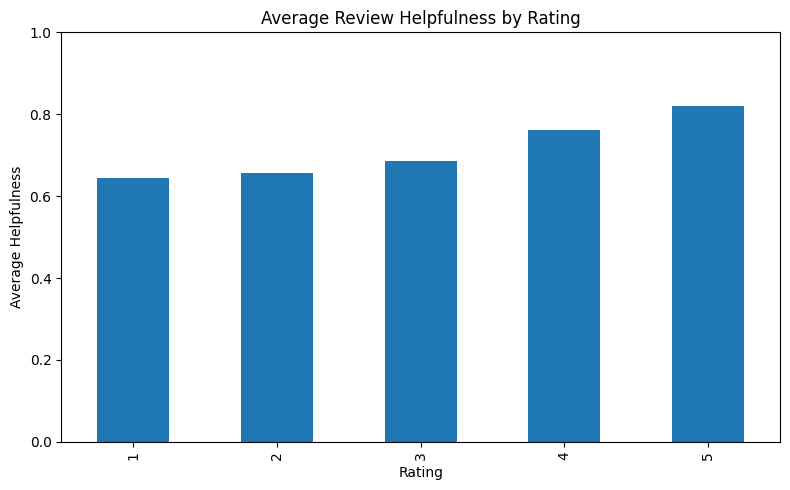

In [45]:
# Average helpfulness by rating

plt.figure(figsize=(8, 5))

helpfulness_by_rating.plot(kind="bar")

plt.title("Average Review Helpfulness by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Helpfulness")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [44]:
# Average helpfulness by rating

helpfulness_by_rating = (
    reviews_0_250
    .dropna(subset=["rating", "helpfulness"])
    .groupby("rating")["helpfulness"]
    .mean()
)

print(helpfulness_by_rating)

rating
1    0.645130
2    0.655473
3    0.686831
4    0.761098
5    0.819791
Name: helpfulness, dtype: float64


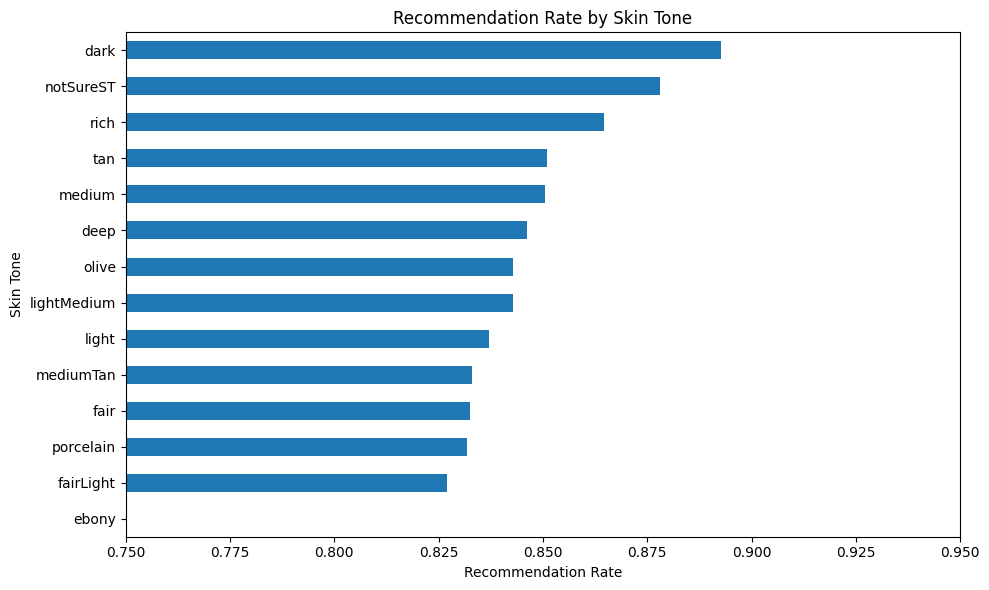

In [43]:
# Recommendation rate by skin tone

plt.figure(figsize=(10, 6))

recommendation_by_skin_tone.sort_values().plot(kind="barh")

plt.title("Recommendation Rate by Skin Tone")
plt.xlabel("Recommendation Rate")
plt.ylabel("Skin Tone")
plt.xlim(0.75, 0.95)

plt.tight_layout()
plt.show()

In [42]:
# Recommendation rate by skin tone

recommendation_by_skin_tone = (
    reviews_0_250
    .dropna(subset=["skin_tone", "is_recommended"])
    .groupby("skin_tone")["is_recommended"]
    .mean()
    .sort_values(ascending=False)
)

print(recommendation_by_skin_tone)

skin_tone
dark           0.892617
notSureST      0.878049
rich           0.864641
tan            0.850983
medium         0.850401
deep           0.846139
olive          0.842872
lightMedium    0.842861
light          0.837120
mediumTan      0.832902
fair           0.832458
porcelain      0.831731
fairLight      0.827029
ebony          0.000000
Name: is_recommended, dtype: float64


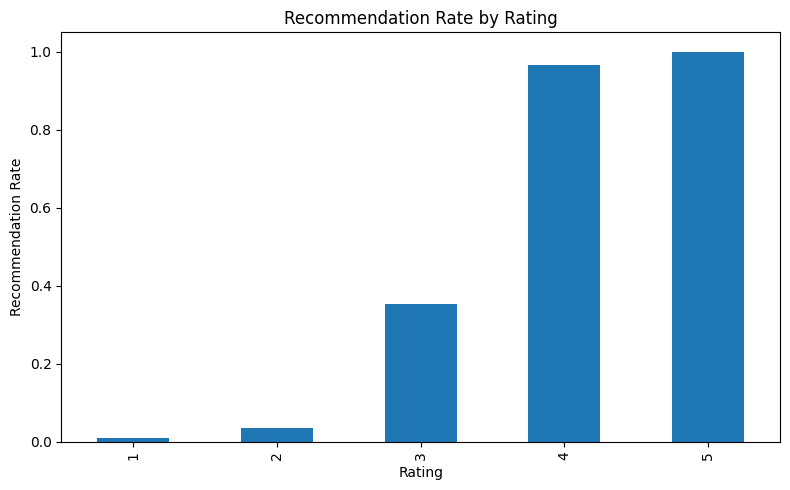

In [41]:
# Recommendation rate by rating

plt.figure(figsize=(8, 5))

recommendation_by_rating.plot(kind="bar")

plt.title("Recommendation Rate by Rating")
plt.xlabel("Rating")
plt.ylabel("Recommendation Rate")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [40]:
# Recommendation rate by rating

recommendation_by_rating = (
    reviews_0_250
    .dropna(subset=["rating", "is_recommended"])
    .groupby("rating")["is_recommended"]
    .mean()
)

print(recommendation_by_rating)

rating
1    0.009068
2    0.036715
3    0.353478
4    0.965232
5    0.998712
Name: is_recommended, dtype: float64


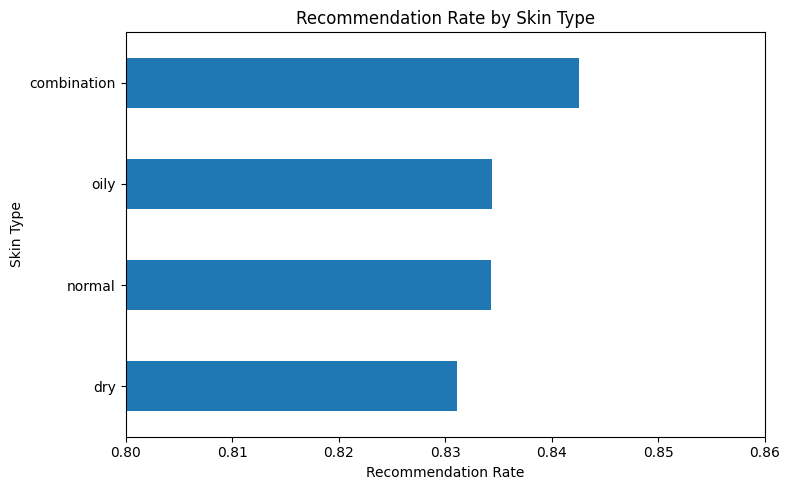

In [39]:
# Recommendation rate by skin type

plt.figure(figsize=(8, 5))

recommendation_by_skin_type.sort_values().plot(kind="barh")

plt.title("Recommendation Rate by Skin Type")
plt.xlabel("Recommendation Rate")
plt.ylabel("Skin Type")
plt.xlim(0.80, 0.86)

plt.tight_layout()
plt.show()

In [38]:
# Recommendation rate by skin type

recommendation_by_skin_type = (
    reviews_0_250
    .dropna(subset=["skin_type", "is_recommended"])
    .groupby("skin_type")["is_recommended"]
    .mean()
    .sort_values(ascending=False)
)

print(recommendation_by_skin_type)

skin_type
combination    0.842583
oily           0.834388
normal         0.834336
dry            0.831103
Name: is_recommended, dtype: float64


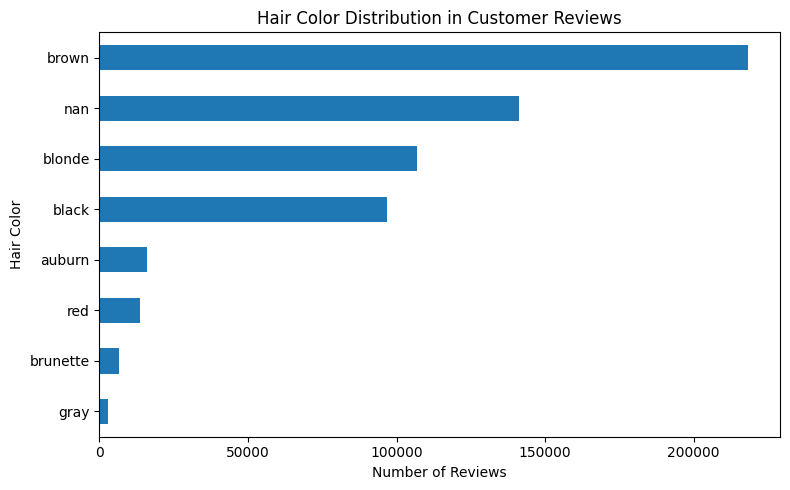

In [37]:
# Hair color distribution

plt.figure(figsize=(8, 5))

hair_color_counts.dropna().sort_values().plot(kind="barh")

plt.title("Hair Color Distribution in Customer Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Hair Color")

plt.tight_layout()
plt.show()

In [36]:
# Hair color distribution

hair_color_counts = (
    reviews_0_250["hair_color"]
    .value_counts(dropna=False)
)

print(hair_color_counts)

hair_color
brown       218139
NaN         141081
blonde      106834
black        96889
auburn       16143
red          13762
brunette      6442
gray          2840
Name: count, dtype: int64


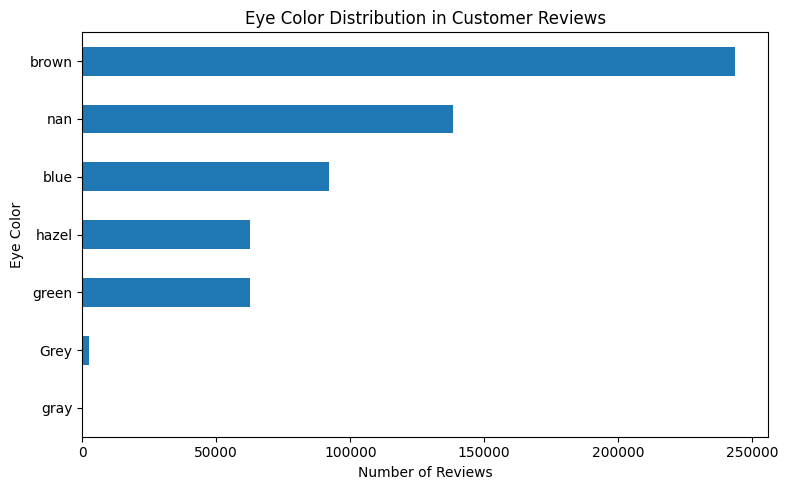

In [35]:
# Eye color distribution

plt.figure(figsize=(8, 5))

eye_color_counts.dropna().sort_values().plot(kind="barh")

plt.title("Eye Color Distribution in Customer Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Eye Color")

plt.tight_layout()
plt.show()

In [34]:
# Eye color distribution

eye_color_counts = (
    reviews_0_250["eye_color"]
    .value_counts(dropna=False)
)

print(eye_color_counts)

eye_color
brown    243751
NaN      138488
blue      91920
hazel     62603
green     62450
Grey       2695
gray        223
Name: count, dtype: int64


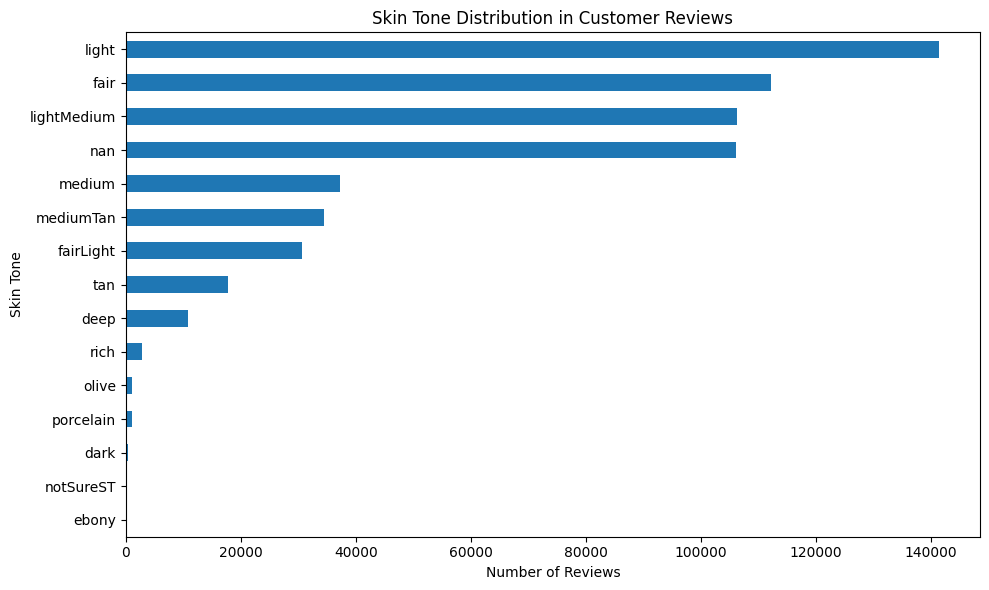

In [33]:
# Skin tone distribution

plt.figure(figsize=(10, 6))

skin_tone_counts.dropna().sort_values().plot(kind="barh")

plt.title("Skin Tone Distribution in Customer Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Skin Tone")

plt.tight_layout()
plt.show()

In [32]:
# Most common skin tones

skin_tone_counts = (
    reviews_0_250["skin_tone"]
    .value_counts(dropna=False)
)

print(skin_tone_counts)

skin_tone
light          141402
fair           112076
lightMedium    106251
NaN            106056
medium          37221
mediumTan       34428
fairLight       30612
tan             17789
deep            10864
rich             2896
olive            1131
porcelain        1040
dark              322
notSureST          41
ebony               1
Name: count, dtype: int64


In [31]:
# Most common review titles

review_title_counts = (
    reviews_0_250["review_title"]
    .dropna()
    .value_counts()
    .head(15)
)

print(review_title_counts)

review_title
Love it!          3421
Amazing           3091
Love it           2790
Amazing!          2478
Great product     1992
Love              1628
Love!             1494
AMAZING           1425
LOVE              1359
love it           1219
amazing           1214
Great product!    1170
Great             1072
Great!            1005
Not for me         977
Name: count, dtype: int64


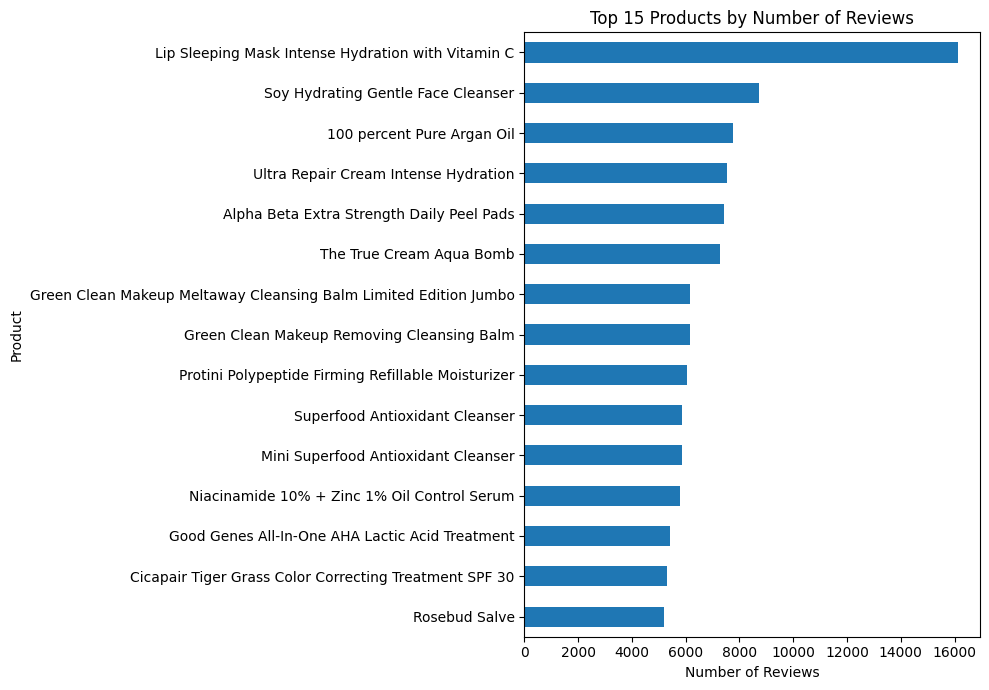

In [30]:
# Top 15 products by number of reviews

plt.figure(figsize=(10, 7))

product_review_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Products by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [29]:
# Most reviewed products

product_review_counts = (
    reviews_0_250["product_name"]
    .value_counts()
    .head(15)
)

print(product_review_counts)

product_name
Lip Sleeping Mask Intense Hydration with Vitamin C                  16138
Soy Hydrating Gentle Face Cleanser                                   8736
100 percent Pure Argan Oil                                           7763
Ultra Repair Cream Intense Hydration                                 7547
Alpha Beta Extra Strength Daily Peel Pads                            7414
The True Cream Aqua Bomb                                             7294
Green Clean Makeup Removing Cleansing Balm                           6169
Green Clean Makeup Meltaway Cleansing Balm Limited Edition Jumbo     6169
Protini Polypeptide Firming Refillable Moisturizer                   6063
Superfood Antioxidant Cleanser                                       5864
Mini Superfood Antioxidant Cleanser                                  5854
Niacinamide 10% + Zinc 1% Oil Control Serum                          5795
Good Genes All-In-One AHA Lactic Acid Treatment                      5400
Cicapair Tiger Grass Colo

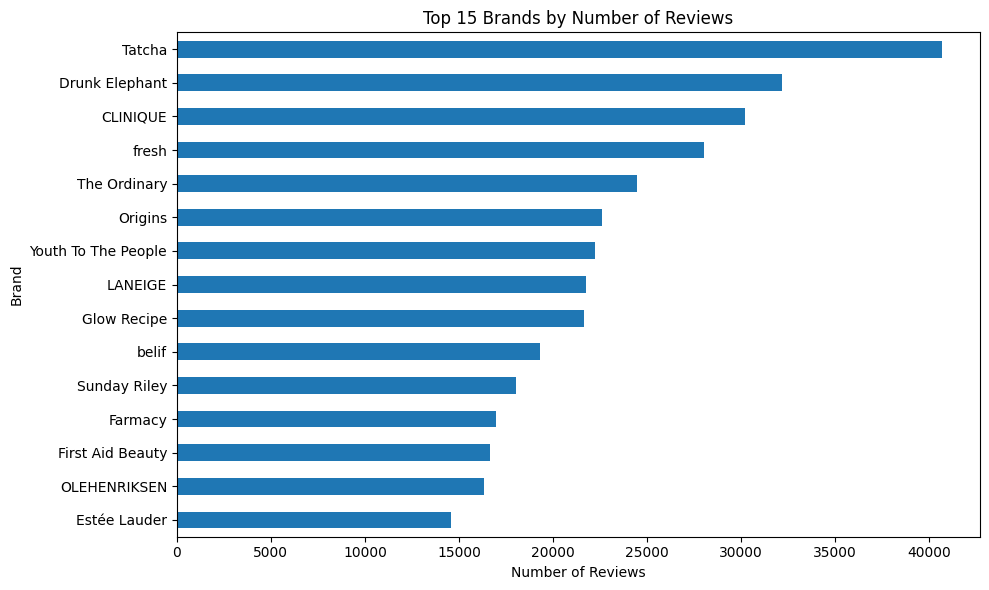

In [28]:
# Top 15 brands by number of reviews

plt.figure(figsize=(10, 6))

brand_review_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Brands by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

In [27]:
# Most reviewed brands

brand_review_counts = (
    reviews_0_250["brand_name"]
    .value_counts()
    .head(15)
)

print(brand_review_counts)

brand_name
Tatcha                 40681
Drunk Elephant         32170
CLINIQUE               30199
fresh                  28057
The Ordinary           24448
Origins                22607
Youth To The People    22249
LANEIGE                21745
Glow Recipe            21639
belif                  19324
Sunday Riley           18013
Farmacy                16969
First Aid Beauty       16675
OLEHENRIKSEN           16328
Estée Lauder           14597
Name: count, dtype: int64


In [26]:
# Check missing and empty review text

missing_review_text = reviews_0_250["review_text"].isna().sum()
empty_review_text = (
    reviews_0_250["review_text"].fillna("").str.strip() == ""
).sum()

print("Missing review text:", missing_review_text)
print("Empty review text:", empty_review_text)

Missing review text: 999
Empty review text: 999


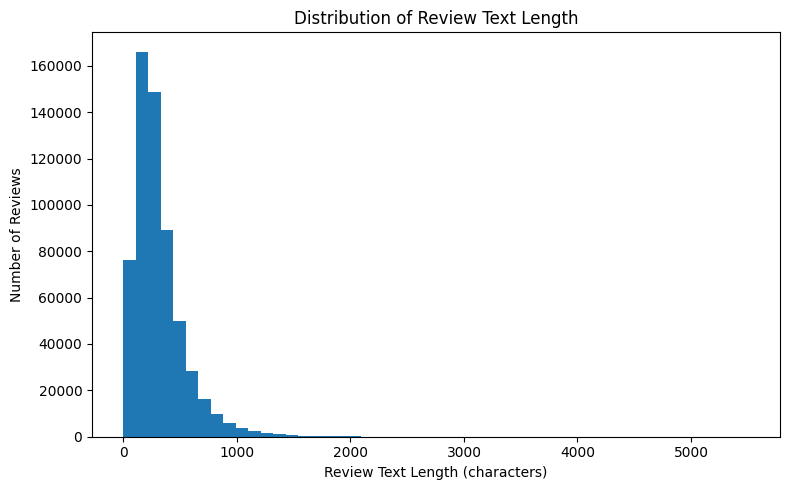

In [25]:
# Review text length distribution

plt.figure(figsize=(8, 5))

plt.hist(
    reviews_0_250["review_text_length"],
    bins=50
)

plt.title("Distribution of Review Text Length")
plt.xlabel("Review Text Length (characters)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [24]:
# Review text length

reviews_0_250["review_text_length"] = (
    reviews_0_250["review_text"]
    .fillna("")
    .str.len()
)

print(reviews_0_250["review_text_length"].describe())

count    602130.000000
mean        314.142954
std         230.255939
min           0.000000
25%         162.000000
50%         258.000000
75%         398.000000
max        5508.000000
Name: review_text_length, dtype: float64


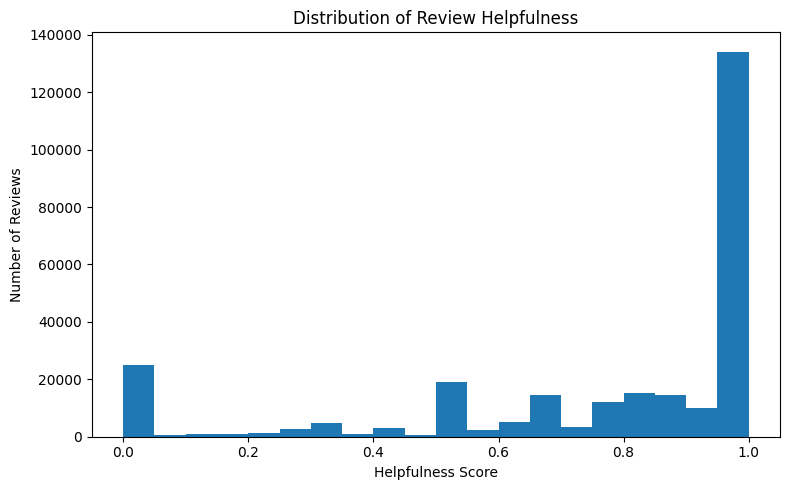

In [23]:
# Review helpfulness distribution

plt.figure(figsize=(8, 5))

plt.hist(
    reviews_0_250["helpfulness"].dropna(),
    bins=20
)

plt.title("Distribution of Review Helpfulness")
plt.xlabel("Helpfulness Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [22]:
# Review helpfulness statistics

print(reviews_0_250["helpfulness"].describe())

count    270298.000000
mean          0.769722
std           0.319103
min           0.000000
25%           0.666667
50%           0.944444
75%           1.000000
max           1.000000
Name: helpfulness, dtype: float64


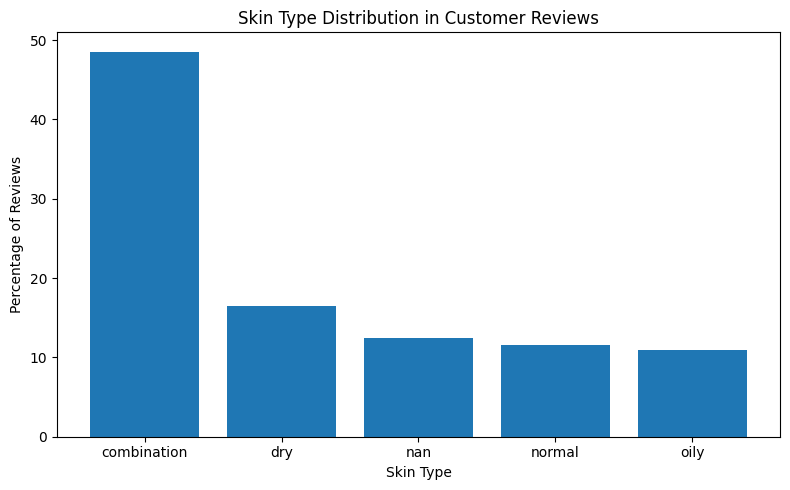

In [21]:
# Review-level skin type distribution chart

review_skin_type_percent = (
    review_skin_type_counts / review_skin_type_counts.sum() * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    review_skin_type_percent.index.astype(str),
    review_skin_type_percent.values
)

plt.title("Skin Type Distribution in Customer Reviews")
plt.xlabel("Skin Type")
plt.ylabel("Percentage of Reviews")

plt.tight_layout()
plt.show()

In [20]:
# Review-level skin type distribution

review_skin_type_counts = (
    reviews_0_250["skin_type"]
    .value_counts(dropna=False)
)

print(review_skin_type_counts)

skin_type
combination    292308
dry             99574
NaN             74683
normal          69435
oily            66130
Name: count, dtype: int64


In [19]:
# Review-level recommendation distribution

review_recommendation_counts = (
    reviews_0_250["is_recommended"]
    .value_counts(dropna=False)
    .sort_index()
)

print(review_recommendation_counts)

is_recommended
0.0     78550
1.0    406094
NaN    117486
Name: count, dtype: int64


In [18]:
# Review-level rating distribution

review_rating_counts = reviews_0_250["rating"].value_counts().sort_index()

print(review_rating_counts)

rating
1     32903
2     29253
3     44018
4    106956
5    389000
Name: count, dtype: int64


In [17]:
# Review dataset columns

print(reviews_0_250.columns.tolist())

['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']


In [16]:
# Load the first review file

reviews_0_250 = pd.read_csv("/content/reviews_0-250.csv")

print("Review dataset shape:", reviews_0_250.shape)

/tmp/ipykernel_981/2267456810.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_0_250 = pd.read_csv("/content/reviews_0-250.csv")


Review dataset shape: (602130, 19)


In [15]:
# Correlation between review count and rating

review_rating_corr = skincare_products[
    ["reviews", "rating"]
].corr().iloc[0, 1]

print(f"Correlation between review count and rating: {review_rating_corr:.3f}")

Correlation between review count and rating: 0.078


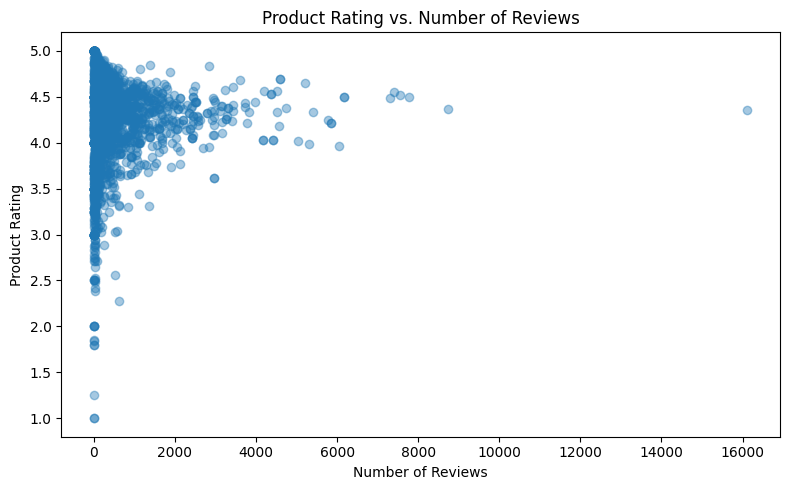

In [14]:
# Review count vs. product rating

plt.figure(figsize=(8, 5))

plt.scatter(
    skincare_products["reviews"],
    skincare_products["rating"],
    alpha=0.4
)

plt.title("Product Rating vs. Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Rating")

plt.tight_layout()
plt.show()

In [13]:
# Correlation between price and rating

price_rating_corr = skincare_products[
    ["price_usd", "rating"]
].corr().iloc[0, 1]

print(f"Correlation between price and rating: {price_rating_corr:.3f}")

Correlation between price and rating: -0.005


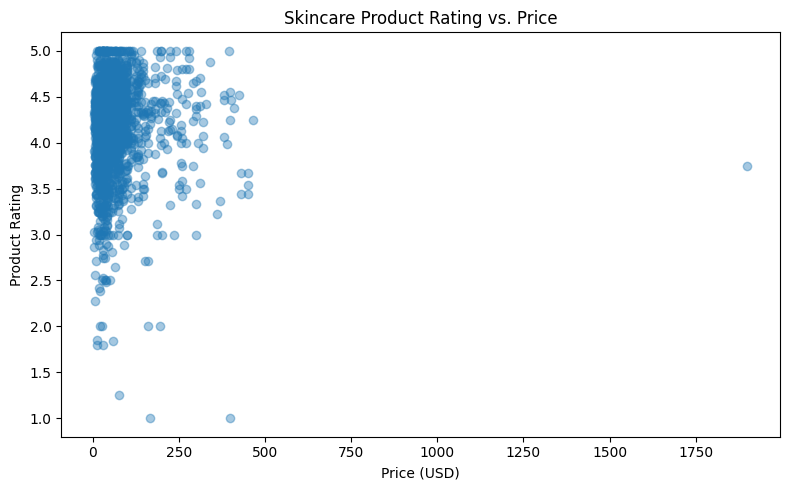

In [12]:
# Rating vs. price

plt.figure(figsize=(8, 5))

plt.scatter(
    skincare_products["price_usd"],
    skincare_products["rating"],
    alpha=0.4
)

plt.title("Skincare Product Rating vs. Price")
plt.xlabel("Price (USD)")
plt.ylabel("Product Rating")

plt.tight_layout()
plt.show()

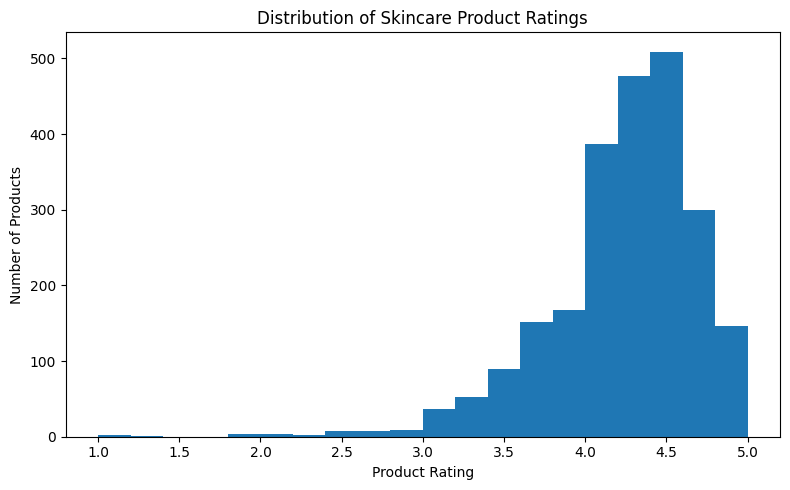

In [11]:
# Distribution of skincare product ratings

plt.figure(figsize=(8, 5))

plt.hist(
    skincare_products["rating"],
    bins=20
)

plt.title("Distribution of Skincare Product Ratings")
plt.xlabel("Product Rating")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [10]:
# Skincare product ratings

rating_summary = skincare_products["rating"].describe()

print(rating_summary)

count    2351.00000
mean        4.22889
std         0.47184
min         1.00000
25%         4.00920
50%         4.31110
75%         4.53880
max         5.00000
Name: rating, dtype: float64


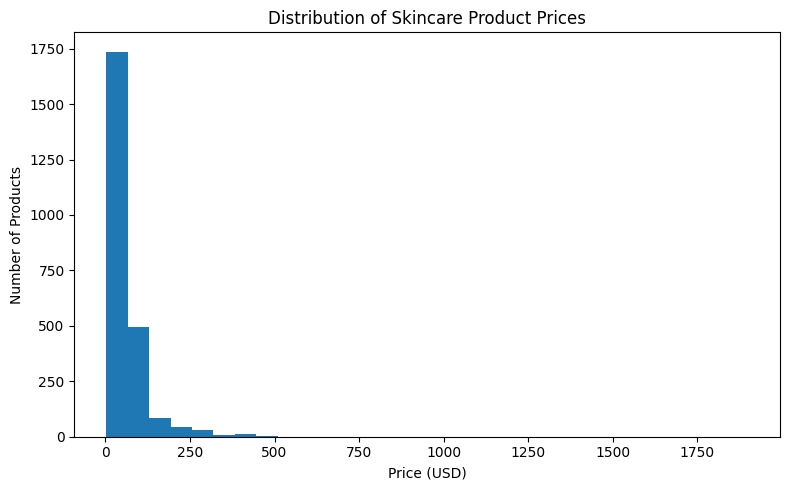

In [9]:
# Skincare price distribution

plt.figure(figsize=(8, 5))

plt.hist(
    skincare_products["price_usd"],
    bins=30
)

plt.title("Distribution of Skincare Product Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

In [8]:
# Skincare price statistics

print(skincare_products["price_usd"].describe())

count    2420.000000
mean       60.512500
std        69.749693
min         3.000000
25%        28.000000
50%        44.000000
75%        70.000000
max      1900.000000
Name: price_usd, dtype: float64


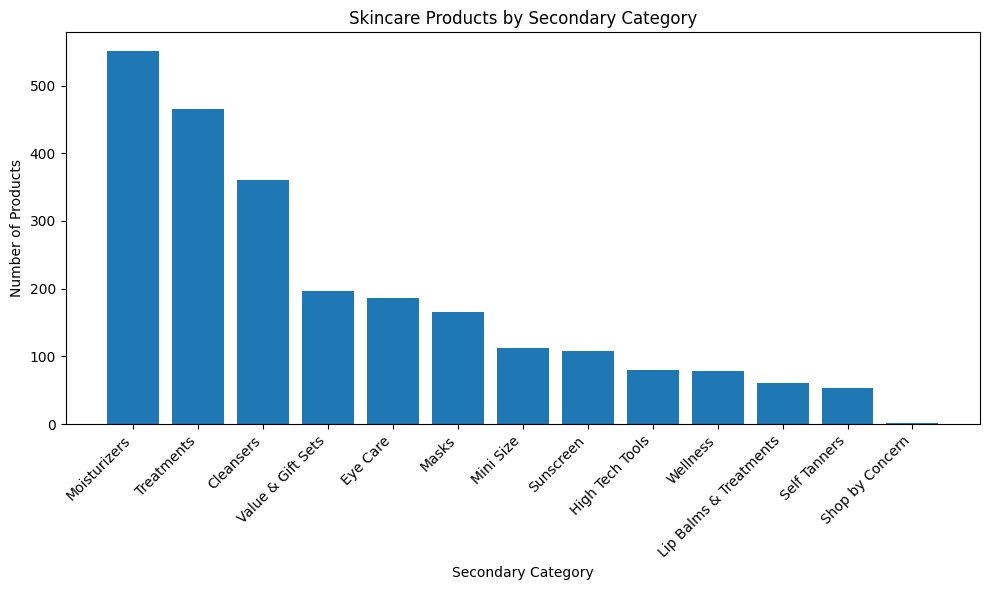

In [7]:
# Skincare products by secondary category

plt.figure(figsize=(10, 6))

plt.bar(
    secondary_counts.index,
    secondary_counts.values
)

plt.title("Skincare Products by Secondary Category")
plt.xlabel("Secondary Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
# Skincare products by secondary category

secondary_counts = (
    skincare_products["secondary_category"]
    .value_counts()
)

print(secondary_counts)

secondary_category
Moisturizers              551
Treatments                466
Cleansers                 361
Value & Gift Sets         196
Eye Care                  186
Masks                     166
Mini Size                 112
Sunscreen                 108
High Tech Tools            80
Wellness                   79
Lip Balms & Treatments     61
Self Tanners               53
Shop by Concern             1
Name: count, dtype: int64


In [5]:
# Filter products to skincare category

skincare_products = products[
    products["primary_category"] == "Skincare"
].copy()

print("Skincare products:", len(skincare_products))

Skincare products: 2420


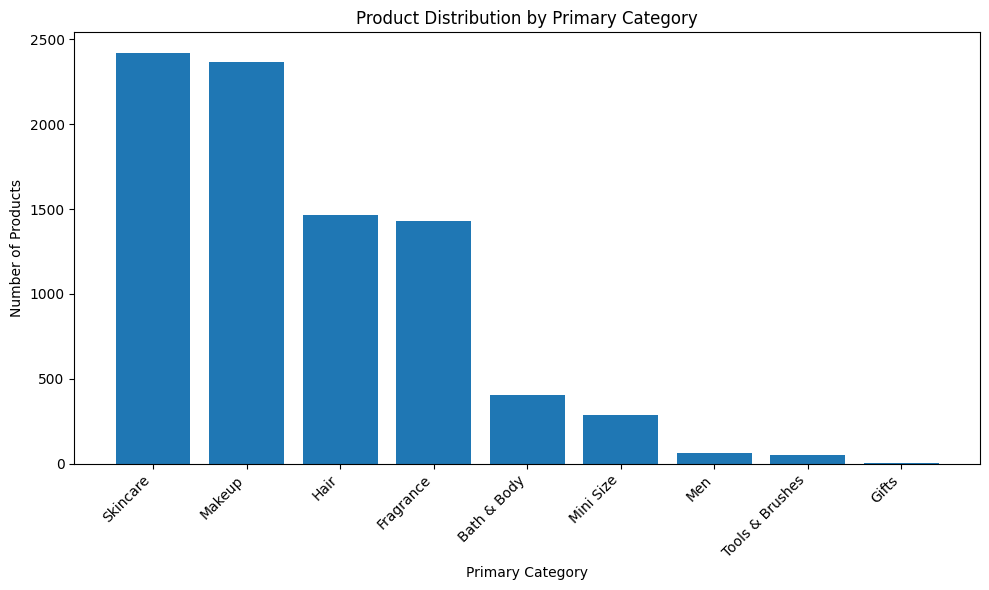

In [4]:
# Product category distribution chart

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Product Distribution by Primary Category")
plt.xlabel("Primary Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [3]:
# Product category distribution

category_counts = products["primary_category"].value_counts()

print(category_counts)

primary_category
Skincare           2420
Makeup             2369
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64


In [2]:
products = pd.read_csv("/content/product_info.csv")

print("Product dataset shape:", products.shape)

Product dataset shape: (8494, 27)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("EDA notebook started")

EDA notebook started
